In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfreqz

Fs = 48000
bands = [
    (22, 44),
    (44, 88),
    (88, 177),
    (177, 355),
    (355, 710),
    (710, 1420),
    (1420, 2840),
    (2840, 5680),
    (5680, 11360),
    (11360, 22720)
]

order = 4

filters = []

for fl, fu in bands:
    sos = butter(
        order,
        [fl, fu],
        btype='bandpass',
        fs=Fs,
        output='sos'
    )
    
    filters.append(sos)

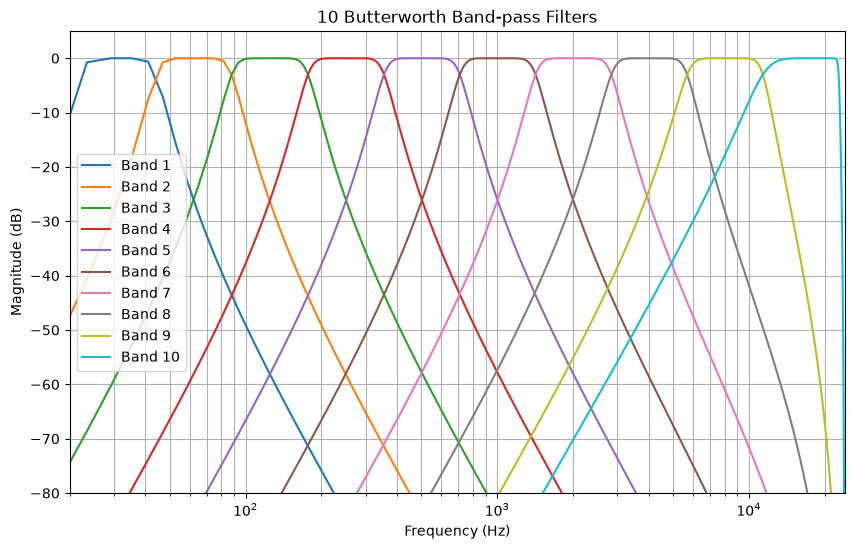

In [2]:
plt.figure(figsize=(10, 6))

for i, sos in enumerate(filters):
    f, h = sosfreqz(
        sos,
        worN=4096,
        fs=Fs
    )

    plt.semilogx(
        f,
        20 * np.log10(np.maximum(np.abs(h), 1e-10)),
        label=f'Band {i+1}'
    )

plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('10 Butterworth Band-pass Filters')
plt.grid(True, which='both')
plt.legend()
plt.xlim(20, 24000)
plt.ylim(-80, 5)
plt.show()